In [2]:
# !curl https://www1.ncdc.noaa.gov/pub/data/igra/data/data-por//USM00072469-data.txt.zip -o USM00072469-data.txt.zip
# !unzip USM00072469-data.txt.zip

In [3]:
# Libraries
import numpy as np
import os as os
from glob import glob
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import sonde_reanalysis_comparison as src
import igra_utils
import igra
import csv
import seaborn as sns
plt.rcParams['figure.dpi'] = 300

In [4]:
# Process new pkl file?
analysis = False

if analysis == True:
    ## IGRA_analysis.py
    # Retrieve and analyze data from IGRA
    # Extracts only RS92 profiles within start_year to end_year (inclusive)

    ### User inputs ###

    # Paths and filenames
    local_path = './raw_data/' # 'data/'
    station_fullpath = 'data/igra2-station-list.txt'
    ignore_filename = 'ignore_list_12to24_V1.csv'
    load_fullpath = './file_to_load_here.pkl' # igra_dataframe_12to16_US_V1.pkl'
    save_fullpath = './Data/IGRA/igra_dataframe_23to24_30_60_global.pkl'
    store_limit = 100 # Save data every N stations
    start_year = 2023
    end_year = 2024

    # World region
    region = 'World' # Choice of 'World', 'US', 'EU', 'Asia'

    ### Simulation set up ###

    # Get list of stations
    stations = igra_utils.download_station_data()
    stations = igra.read.stationlist( station_fullpath )

    # Stations active between 2012 - 2024
    index = (stations['end']>=start_year) & (stations['start']<=end_year)

    # Clean up
    active_stations = stations.loc[ index ]
    active_stations['wmo'] = pd.to_numeric( active_stations['wmo'] )
    active_stations.reset_index( inplace=True )

    # Load in WMO station information
    wmo_info = pd.read_excel( 'WMO_sondetype.xls', 'RaRaRawGST' )
    wmo_info = wmo_info[ wmo_info[ 'instrument' ].str.contains( 'RS92' ) ]
    wmo_info['station_index_numeric'] = pd.to_numeric( wmo_info['station_index'], errors='coerce' )

    # Merge stations with wmo info
    active_stations = pd.merge( left=active_stations, right=wmo_info, how='left', left_on='wmo', right_on='station_index_numeric' )
    active_stations.dropna( subset=['instrument'], inplace=True )
    active_stations.reset_index( drop=True, inplace=True )
    active_stations.set_index( 'id', inplace=True )

    # Load ignore_list
    if os.path.exists( ignore_filename ):
        print( 'Loading ignore list...' )
        with open( ignore_filename, newline='' ) as f:
            data = csv.reader(f)
            ignore_list = list( data )[0]
    else:
        ignore_list = []

    # Load if dataframe saved before
    if os.path.exists( load_fullpath ):
        print( 'Loading existing dataframe...' )
        active_data = pd.read_pickle( load_fullpath )
    else:
        active_data = None

    # Get only active stations in region we care about
    if region == 'World':
        LON_EXTENT = [ -200, 200 ] # [ -30, 50 ] # [ -135, -65 ]
        LAT_EXTENT = [ 30, 60 ] #[ -200, 200 ] # [ 30, 70 ] # [ 10, 50 ]
    elif region == 'US':
        LON_EXTENT = [ -140, -40 ]
        LAT_EXTENT = [ 10, 70 ]
    elif region == 'EU':
        LON_EXTENT = [ -200, 200 ] # [ -30, 50 ] # [ -135, -65 ]
        LAT_EXTENT = [ -200, 200 ] # [ 30, 70 ] # [ 10, 50 ]
    elif region == 'Asia':
        LON_EXTENT = [ -200, 200 ] # [ -30, 50 ] # [ -135, -65 ]
        LAT_EXTENT = [ -200, 200 ] # [ 30, 70 ] # [ 10, 50 ]
    else:
        raise Exception( 'Desired region (%s) does not exist' %( region ) )

    ### Simulation ###

    # Loop over stations and figure out number of sondes within date range
    if active_data is None:
        last_save = 0
    else:
        last_save = len(active_data.location.unique())
    ii = last_save

    print( 'Total number of stations: %d' %(len(active_stations)) )
    print( 'Starting number: %d' %(ii) )
    for station_id, row in active_stations.iterrows():

        # Break early if needed
        if ii>=10:
            break
        
        # Save early if needed
        if ii >= last_save + store_limit:
            print( 'Saving data!!!' )
            active_data.to_pickle( save_fullpath )
            # Save ignore_list as well
            if os.path.exists( ignore_filename ):
                os.remove( ignore_filename )
            with open( ignore_filename, 'w', newline='') as myfile:
                 wr = csv.writer( myfile, quoting=csv.QUOTE_ALL )
                 wr.writerow( ignore_list )
            last_save = ii
            # break

        # Station filename to download
        filename = '%s*.zip' %( station_id )
        local_fullpath = '%s/%s' %( local_path, filename )
        # print(filename, row['name'])

        # Skip if station in ignore_list
        if station_id in ignore_list:
            print('Skipping... %s' %(station_id))
            continue
    
        # Check if station already exists in active_data
        if active_data is not None:
            if (active_data['location']==station_id).any():
                print('Case #%d: Data for %s exists... Skipping' %(ii+1, row['name']))
                ii+=1
                continue
            
        # Check location
        if (row['lat']>=LAT_EXTENT[0]) & (row['lat']<=LAT_EXTENT[1]) & (row['lon']>=LON_EXTENT[0]) & (row['lon']<=LON_EXTENT[1]):
            print('Case #%d: Working on %s...' %(ii+1, row['name']))
        else:
            continue
        
        # Download data if it doesn't exist
        if not glob( local_fullpath ):
            print('Downloading data for %s' %(row['name']))
            print( station_id, local_path )
            igra.download.station( station_id, local_path ) # 'data/' )

        # Load data
        local_fullpath = glob( local_path + '/' + station_id + '*.zip' )[0]
        data, stat = igra.read.ascii_to_dataframe( local_fullpath )

        # Only select data for specific years
        years = data.index.year
        active_mask = (years>=2023) & (years<=2024)
        main_data = data.loc[active_mask]
        main_data['location'] = station_id # row['name'] --> name is not necessarily unique but id is

        # Reset so that date becomes a column
        main_data = main_data.reset_index()

        # Check if rhumi or dewpoint depression always null
        rhumi_always_null = main_data['rhumi'].isnull().all()
        dpd_always_null = main_data['dpd'].isnull().all()

        # Decision point if nulls
        if not dpd_always_null: # Use the dew point depression to begin with
            # Drop nan rows and set RH value to this column
            main_data.dropna( subset=['dpd'], inplace=True )
            main_data['RH'] = src.dpd2RH( main_data['dpd'].values, main_data['temp'].values )
            ii += 1
        elif not rhumi_always_null:
            # Drop nan rows and set RH value to this column
            main_data.dropna( subset=['rhumi'], inplace=True )
            main_data['RH'] = main_data['rhumi']
            ii += 1
        else:
            print('All nulls... adding to ignore_list')
            # Add to ignore_list
            ignore_list.append( station_id )
            continue
        
        # Convert units for ease of use
        main_data['pres'] = main_data['pres']/100 # Pa to hPa
        main_data['temp'] = main_data['temp'] + 273.15 # C to K

        # Add RHi and SAC information
        main_data['RHi'] = src.RHw2RHi( main_data['RH'], main_data['temp'] ) # 1*(main_data['rhumi']>=60)
        main_data['SAC'] = src.SAC_general( main_data['RH'], main_data['temp'], main_data['pres'] )

        # Apply correction algorithm to IGRA data
        main_data[ 'Tcorr' ], main_data[ 'RHcorr' ] = \
                     igra_utils.radcorr( row['lat'], row['lon'], main_data['date'].values[0],\
                     main_data['pres'].values, main_data['temp'].values, main_data['RH'].values )
        main_data[ 'RHicorr' ] = src.RHw2RHi( main_data['RHcorr'], main_data['Tcorr'] )
        main_data[ 'SACcorr' ] = src.SAC_general( main_data['RHcorr'], main_data['Tcorr'], main_data['pres'] )

        if active_data is None:
            active_data = main_data.copy()
        else:
            active_data = pd.concat( [active_data, main_data], ignore_index=True )
            # Convert types to save memory
            active_data[ 'location' ] = active_data[ 'location' ].astype('category')
            active_data[ 'SAC' ] = active_data[ 'SAC' ].astype('bool')

    ### Simulation clear up    

    # Convert types to save memory
    active_data[ 'location' ] = active_data[ 'location' ].astype('category')
    active_data[ 'SAC' ] = active_data[ 'SAC' ].astype('bool')

    # Save as pickle
    print( 'Completed simulation - saving data and ignore_filename...' ) 
    active_data.to_pickle( save_fullpath )

    # Save ignore_list
    if os.path.exists( ignore_filename ):
        os.remove( ignore_filename )
    with open( ignore_filename, 'w', newline='') as myfile:
         wr = csv.writer( myfile, quoting=csv.QUOTE_ALL )
         wr.writerow( ignore_list )

    print( 'Simulation complete!' )


In [5]:
# view data
import pickle 
  
# Open the file in binary mode 
with open('/home/chinahg/GCresearch/misc_scripts_old/IGRA_processing/Data/IGRA/igra_dataframe_12to22_global.pkl', 'rb') as file: 
      
    # Call load method to deserialze 
    myvar = pickle.load(file) 

In [6]:
# i = 0
# for i in range(len(myvar.RHicorr)):
#     if myvar.RHicorr[i] >= 100:
#         print("index: ", i ," Value: ", myvar.RHicorr[i])

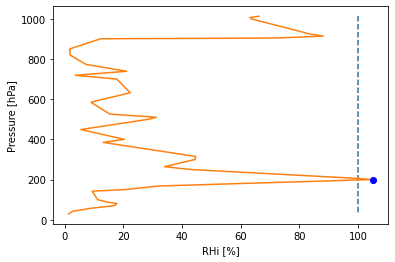

In [7]:
plt.xlabel("RHi [%]")
plt.ylabel("Pressure [hPa]")
plt.plot(100*np.ones(45), myvar.pres[333:378], linestyle='dashed')
plt.plot(myvar.RHicorr[333:378], myvar.pres[333:378])
plt.plot(myvar.RHicorr[362]*myvar.SACcorr[362], myvar.pres[362], linestyle='dotted', marker='o', color='b')

In [8]:
# Print relative humidity at 10km (approx 265 hPa)
cruiseRH = []
MLD_array_pres = []
MLD_top = []
MLD_bottom = []
RH_len = len(myvar.RHicorr)
L = -6.5*10**-3 # lapse rate [K/m]
P0 = 101325 # pressure at 0 alt [Pa]
T0 = 288.15 # temp at 0 alt [K]
R = 287.053 # gas constant for air [J/kgK]
g = 9.81 #acceleration due to gravity [m/s^2]
print((T0/L)*((250*100/P0)**(-L*R/g) - 1))

for i in range(RH_len): # look through all RH datapoints for all dates and locations

    if myvar.pres[i] >= 250 and myvar.pres[i] <= 290 and myvar.RHicorr[i] >= 100: # if pressure is approx 265 hPa and RH > 100% record RH

        cruiseRH.append(myvar.RHicorr[i])

        # Convert MLD to altitude [m] (https://archive.psas.pdx.edu/RocketScience/PressureAltitude_Derived.pdf)
        MLD_top.append((T0/L)*((myvar.pres[i]*100/P0)**(-L*R/g) - 1))

        for j in range(RH_len): # Look through list of RH under cruise alt and determine MLD

            if myvar.RHicorr[i-j] < 100: # MLD ends when RHi < 100%
                MLD_index = i-j
                if myvar.pres[MLD_index] < myvar.RHicorr[i]: # if we accidentally bleed into the next radisonde profile then assume MLD is from cruise until ground level
                     MLD_array_pres.append(1015) # make min altutude RS92 records
                     MLD_bottom.append((T0/L)*((myvar.pres[MLD_index]*100/P0)**(-L*R/g) - 1))
                else:
                    MLD_array_pres.append(myvar.pres[MLD_index])
                    MLD_bottom.append((T0/L)*((myvar.pres[MLD_index]*100/P0)**(-L*R/g) - 1))
                    
                break

MLD_array_alt = np.zeros(len(MLD_top))
# Take difference of altitudes to get MLD in [m]
for k in range(len(MLD_top)):
    MLD_array_alt[k] = (MLD_top[k]-MLD_bottom[k])

10359.854482111912


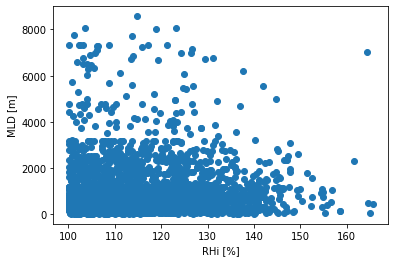

In [9]:
plt.xlabel("RHi [%]")
plt.ylabel("MLD [m]")
plt.scatter(cruiseRH , MLD_array_alt)

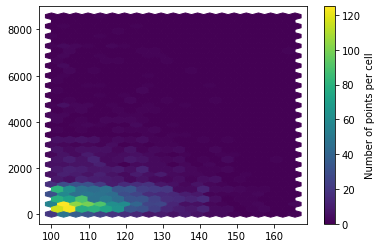

In [10]:
# Heatmap version
#cruiseRH, MLD_array = np.meshgrid(cruiseRH,MLD_array)
#cruiseRH = cruiseRH.ravel()
#MLD_array = MLD_array.ravel()

plt.hexbin(cruiseRH, MLD_array_alt, gridsize = (20,20))
cb = plt.colorbar()
cb.set_label('Number of points per cell')


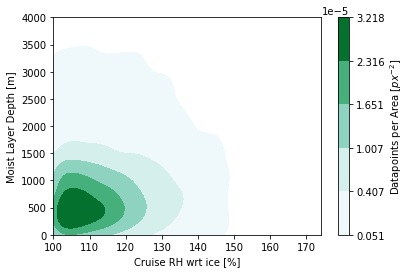

In [11]:
# Contour version
ax = sns.kdeplot(x = cruiseRH, y = MLD_array_alt, bw_adjust=1, zorder=0, n_levels=6, fill=True, 
    cbar=True, cmap='BuGn', cbar_kws={'label': 'Datapoints per Area [$px^{-2}$]'})
ax.set(xlabel = "Cruise RH wrt ice [%]")
ax.set(ylabel = "Moist Layer Depth [m]")
plt.ylim(bottom = 0, top = 4000)
plt.xlim(left = 100)


plt.show()

In [12]:
print(len(MLD_array_alt))

3838
